In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

# Ensure reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# --- 1. Load dataset ---
df = pd.read_csv("/content/Clinical_Data_Discovery_Cohort_LARGE.csv")

print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

# Rename target column for consistency
df = df.rename(columns={"Event (death=1, alive=0)": "Event"})

Dataset shape:
(1000, 15)

First 5 rows:
  Patient ID  Age     Sex  Tumor size (cm)  Grade Stage (TNM)  \
0    P100000   73    Male              6.1      3        IIIA   
1    P100001   57  Female              0.9      1         IIB   
2    P100002   36  Female              5.6      2          IB   
3    P100003   78    Male              0.7      3        IIIA   
4    P100004   49  Female              3.7      1         IIB   

   Survival time (days)  Event (death=1, alive=0) Smoking Status  Pack Years  \
0                  1388                         1          Never        59.7   
1                  2707                         0        Current        70.8   
2                  2824                         1         Former        61.7   
3                   616                         1        Current         4.7   
4                  3379                         0          Never        51.4   

    Treatment Type EGFR Mutation    KRAS Mutation    Hospital  \
0        Radiation    

In [3]:
# --- 2. Perform preprocessing ---
X = df.drop("Event", axis=1)
y = df["Event"]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor object using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [4]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform the training data, transform the testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Determine input shape for the model
input_shape = X_train_processed.shape[1]

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed testing data shape: {X_test_processed.shape}")
print(f"Model input shape: {input_shape}")

Processed training data shape: (800, 841)
Processed testing data shape: (200, 841)
Model input shape: 841


In [5]:
# --- 3. Build model using TensorFlow/Keras ---
# --- 4. Train model using SGD, Adam, RMSProp ---
# --- 5. Apply regularization: Dropout, L1/L2, EarlyStopping ---
# --- 6. Hyperparameter tuning (basic) ---

def build_and_train_model(optimizer_name, learning_rate, batch_size, n_neurons, dropout_rate, l1_reg, l2_reg, X_train, y_train, X_test, y_test, epochs=100):
    print(f"\n--- Training with {optimizer_name} (LR: {learning_rate}, Batch: {batch_size}, Neurons: {n_neurons}) ---")

    model = Sequential([
        Dense(n_neurons, activation='relu', input_shape=(input_shape,),
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        Dropout(dropout_rate),
        Dense(n_neurons // 2, activation='relu',
              kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid') # Binary classification
    ])

    if optimizer_name == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer")

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_test, y_test),
                        callbacks=[early_stopping],
                        verbose=0) # Set verbose to 0 to suppress output for each epoch

    return model, history

In [6]:
models = {}
histories = {}

# Hyperparameter combinations to test (basic tuning)
optimizers_to_test = ['Adam', 'SGD', 'RMSprop']
learning_rates = {'Adam': 0.001, 'SGD': 0.01, 'RMSprop': 0.001} # Fixed learning rates for simplicity for each optimizer
batch_sizes = [32, 64] # Test two batch sizes
n_neurons_options = [64, 128] # Test two neuron counts for the first layer

# Fixed regularization and dropout for now
dropout_rate = 0.3
l1_reg = 0.001
l2_reg = 0.001

best_model = None
best_accuracy = -1
best_model_name = ""

# Iterate through optimizers and basic hyperparameters
for optimizer_name in optimizers_to_test:
    for batch_size in batch_sizes:
        for n_neurons in n_neurons_options:
            current_lr = learning_rates[optimizer_name]
            model_name = f"{optimizer_name}_LR{current_lr}_BS{batch_size}_N{n_neurons}"
            model, history = build_and_train_model(optimizer_name, current_lr, batch_size, n_neurons, dropout_rate, l1_reg, l2_reg, X_train_processed, y_train, X_test_processed, y_test)
            models[model_name] = model
            histories[model_name] = history

            # Evaluate current model
            y_pred_proba = model.predict(X_test_processed, verbose=0)
            y_pred = (y_pred_proba > 0.5).astype(int)
            current_accuracy = accuracy_score(y_test, y_pred)
            print(f"Model: {model_name}, Test Accuracy: {current_accuracy:.4f}")

            if current_accuracy > best_accuracy:
                best_accuracy = current_accuracy
                best_model = model
                best_model_name = model_name

print(f"\nBest model found: {best_model_name} with accuracy: {best_accuracy:.4f}")


--- Training with Adam (LR: 0.001, Batch: 32, Neurons: 64) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: Adam_LR0.001_BS32_N64, Test Accuracy: 0.6800

--- Training with Adam (LR: 0.001, Batch: 32, Neurons: 128) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: Adam_LR0.001_BS32_N128, Test Accuracy: 0.6800

--- Training with Adam (LR: 0.001, Batch: 64, Neurons: 64) ---


...

Model: RMSprop_LR0.001_BS32_N128, Test Accuracy: 0.6750

--- Training with RMSprop (LR: 0.001, Batch: 64, Neurons: 64) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: RMSprop_LR0.001_BS64_N64, Test Accuracy: 0.6650

--- Training with RMSprop (LR: 0.001, Batch: 64, Neurons: 128) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: RMSprop_LR0.001_BS64_N128, Test Accuracy: 0.6600

Best model found: Adam_LR0.001_BS32_N64 with accuracy: 0.6800


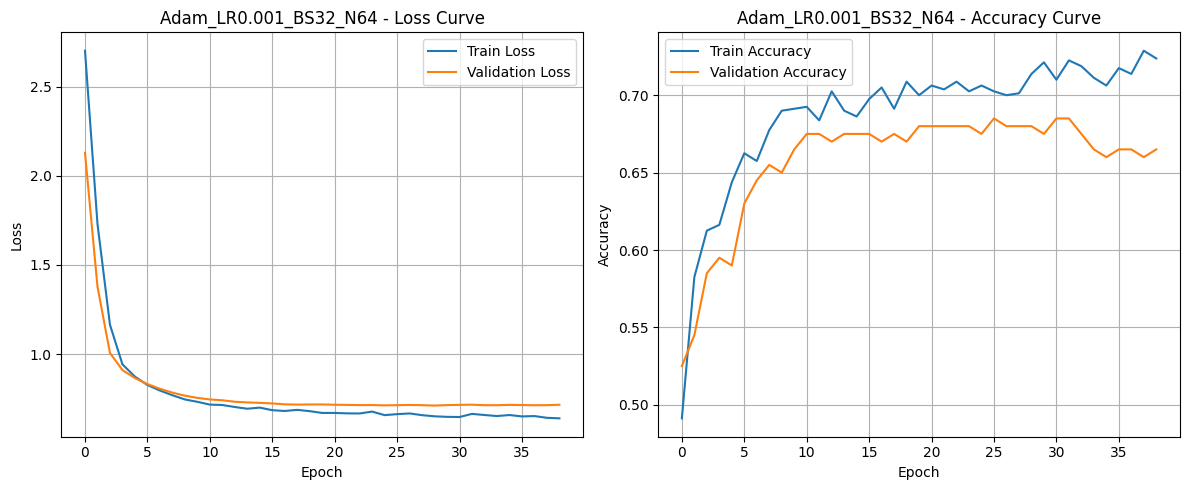

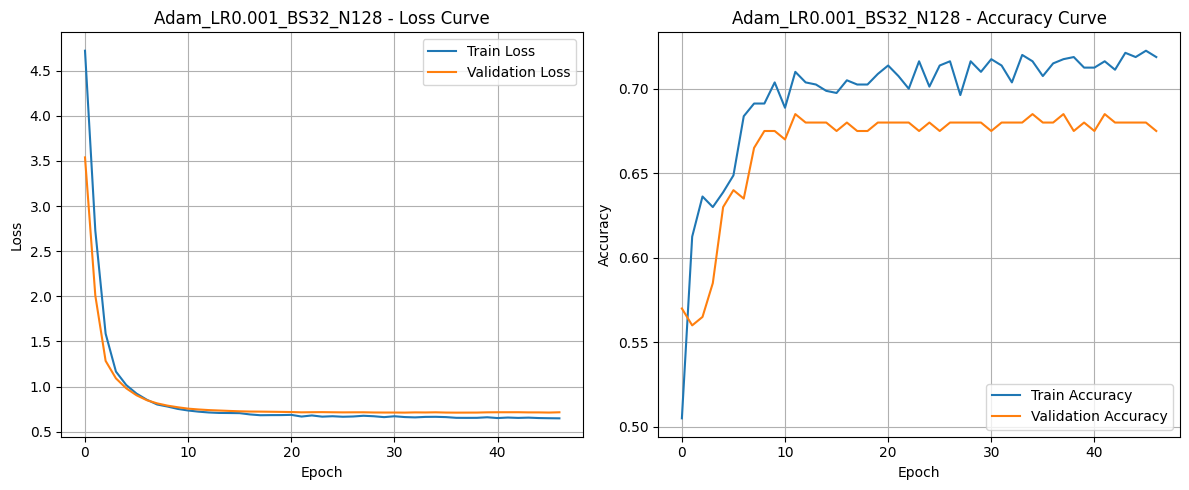

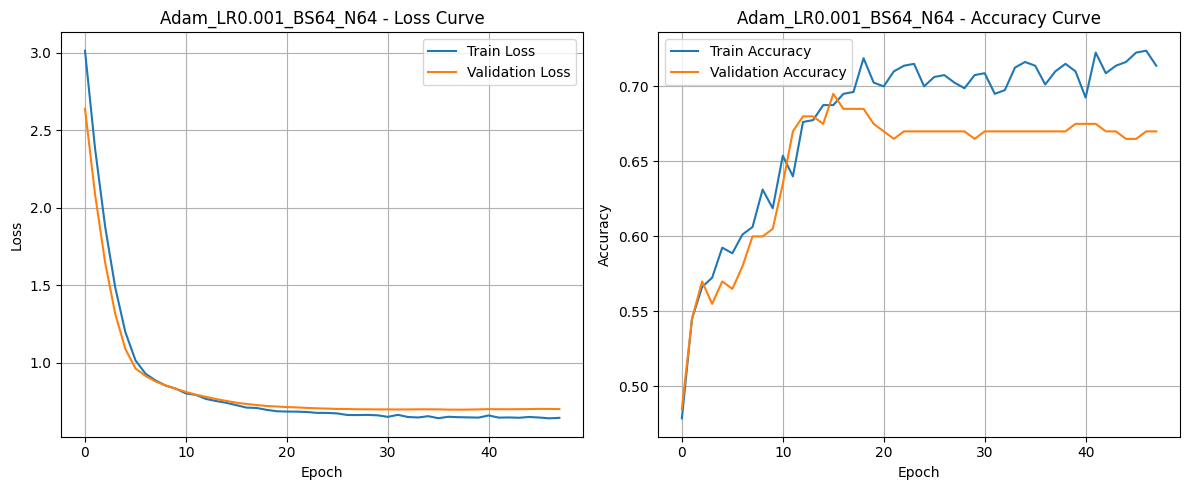

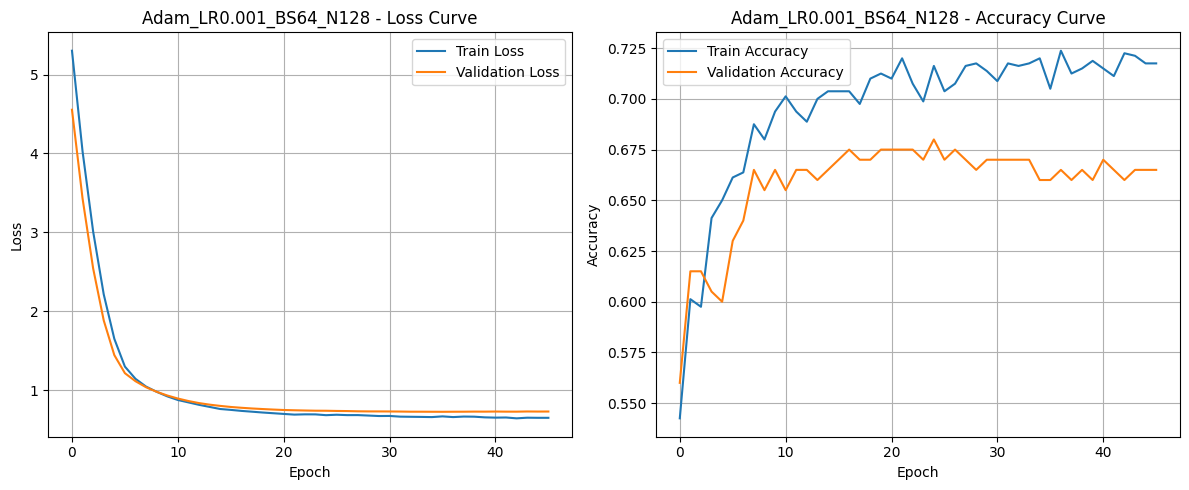

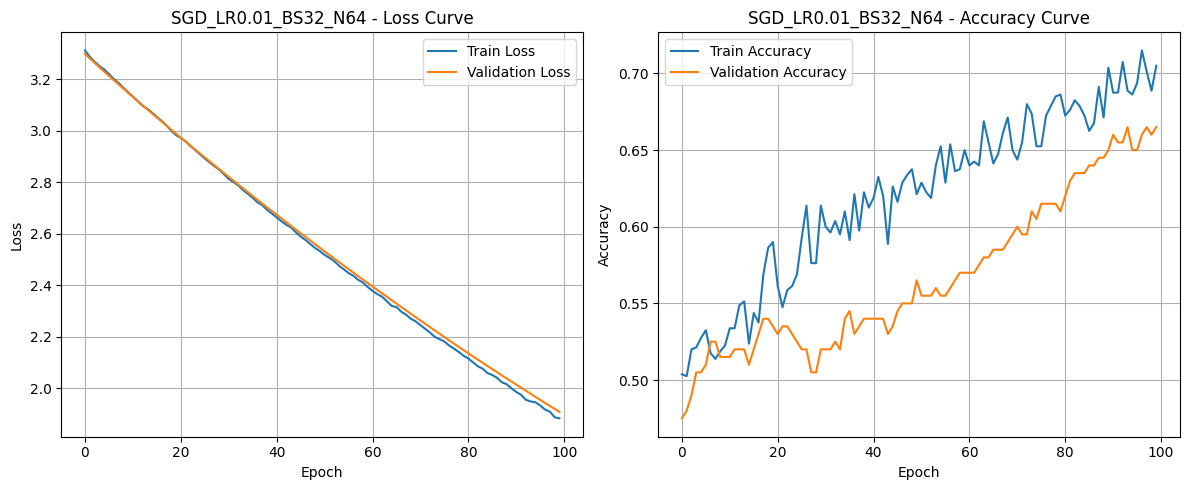

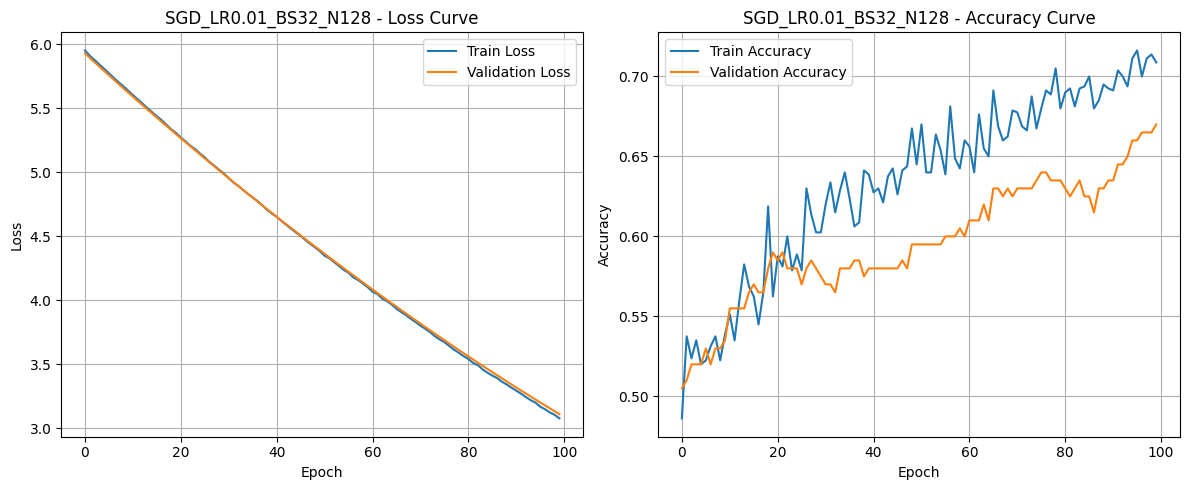

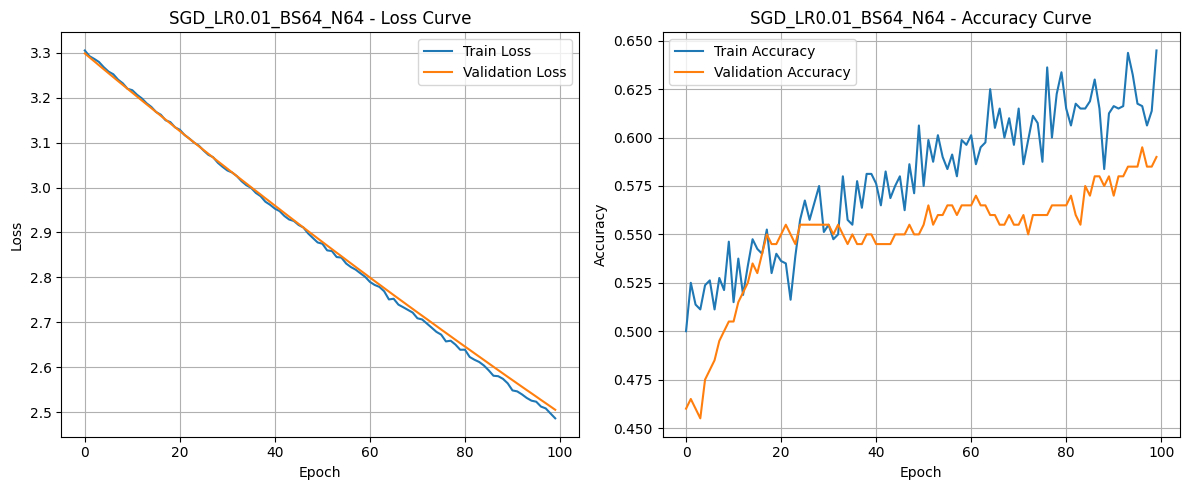

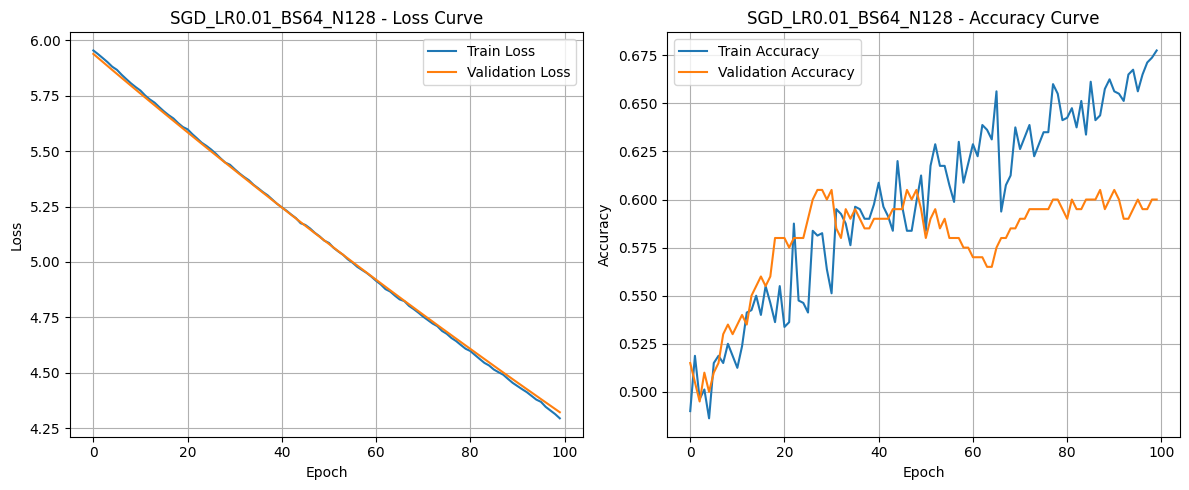

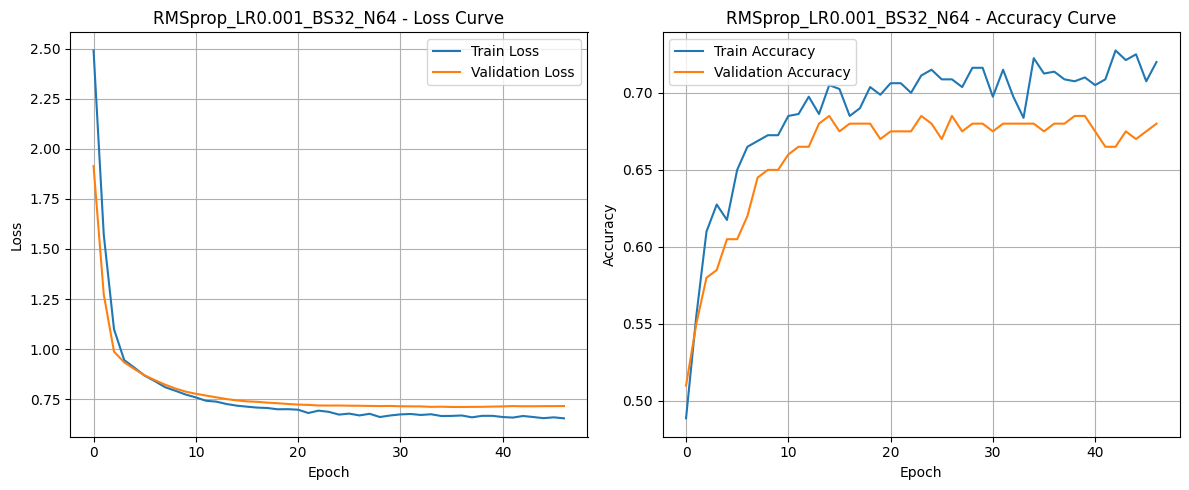

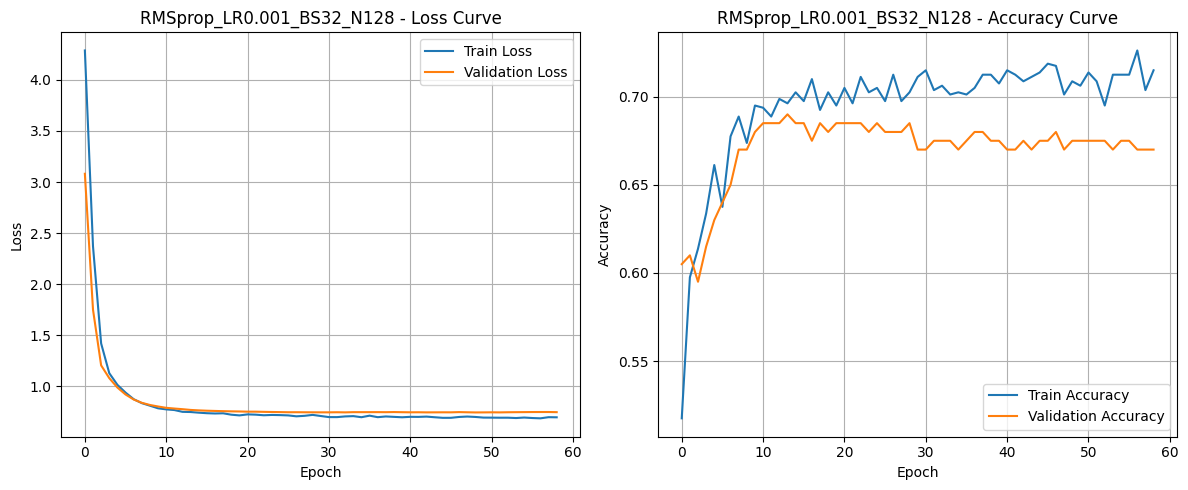

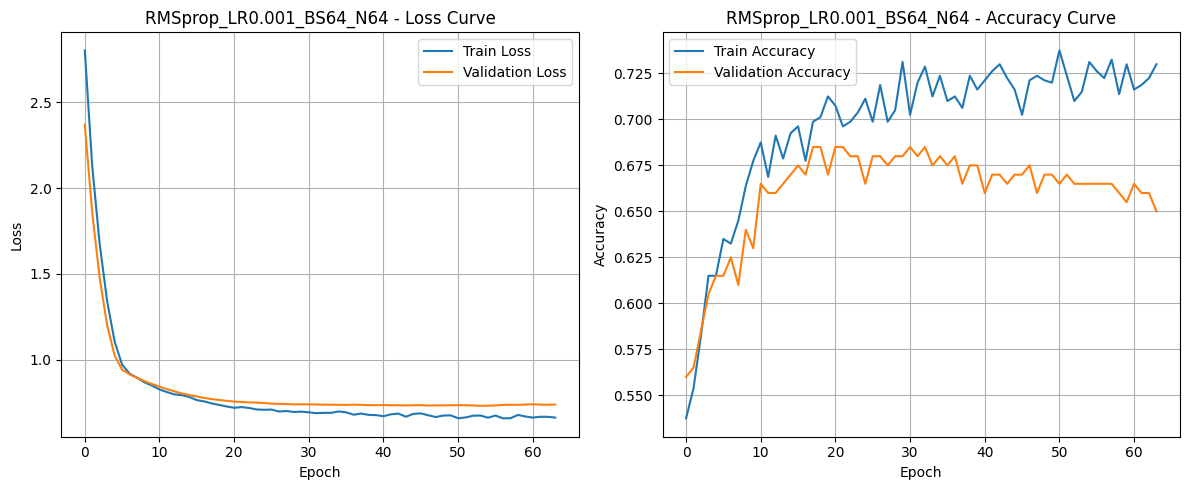

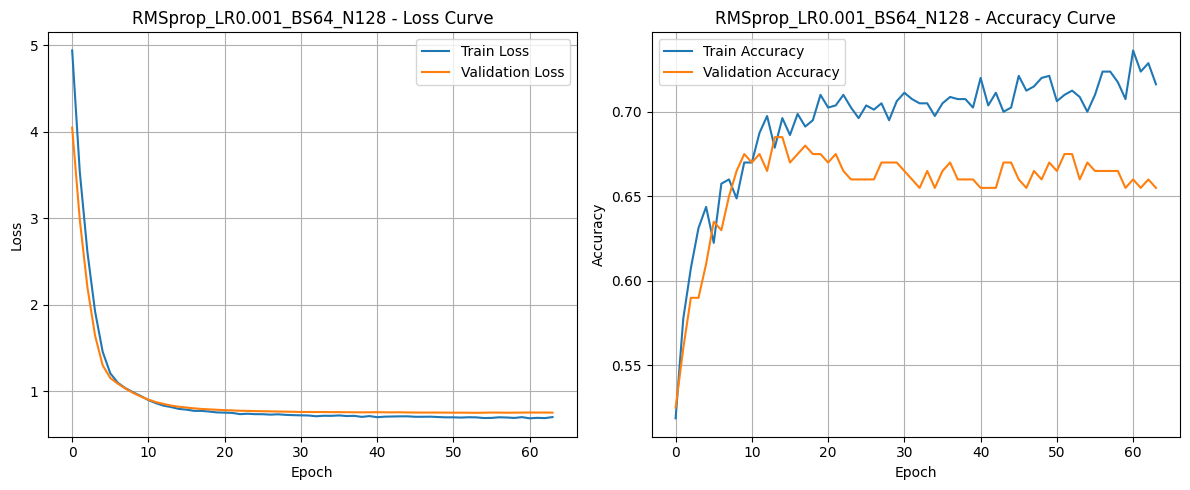

In [7]:
# --- 7. Plot graphs using matplotlib ---
# --- 12. Visualization: Plot accuracy/loss curves clearly ---

for model_name, history in histories.items():
    plt.figure(figsize=(12, 5))

    # Plot Training & Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Training & Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


--- Evaluation for the Best Model: Adam_LR0.001_BS32_N64 ---
Test Loss: 0.7107
Test Accuracy: 0.6800

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.81      0.72       104
           1       0.72      0.54      0.62        96

    accuracy                           0.68       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.69      0.68      0.67       200



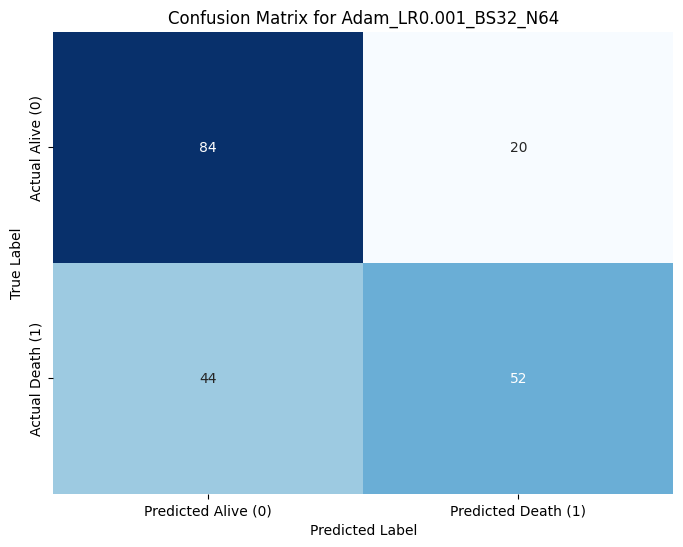

In [8]:
# --- 8. Evaluate performance for the best model ---
# --- 12. Visualization: Plot confusion matrix ---

print(f"\n--- Evaluation for the Best Model: {best_model_name} ---")

# Evaluate on test set
loss, accuracy = best_model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Predictions for F1 Score and Confusion Matrix
y_pred_proba_best = best_model.predict(X_test_processed, verbose=0)
y_pred_best = (y_pred_proba_best > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Alive (0)', 'Predicted Death (1)'],
            yticklabels=['Actual Alive (0)', 'Actual Death (1)'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [9]:
# --- 9. Print model summary for the best model ---
print(f"\n--- Model Summary for the Best Model: {best_model_name} ---")
best_model.summary()

# --- 10. Save best model ---
model_save_path = "clinical_survival_model.h5"
best_model.save(model_save_path)
print(f"\nBest model saved to {model_save_path}")


--- Model Summary for the Best Model: Adam_LR0.001_BS32_N64 ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        53,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,005 (656.27 KB)

 Trainable params: 56,001 (218.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112,004 (437.52 KB)


Best model saved to clinical_survival_model.h5


In [11]:
# --- 11. Extra: Print predictions on few samples ---
print("\n--- Predictions on a few test samples ---")
num_samples_to_predict = 5
sample_indices = np.random.choice(X_test_processed.shape[0], num_samples_to_predict, replace=False)
sample_X = X_test_processed[sample_indices]
sample_y_true = y_test.iloc[sample_indices]

sample_predictions_proba = best_model.predict(sample_X, verbose=0)
sample_predictions_classes = (sample_predictions_proba > 0.5).astype(int)

for i in range(num_samples_to_predict):
    print(f"Sample {i+1}:")
    print(f"  True Label: {sample_y_true.iloc[i]}")
    print(f"  Predicted Probability (Death=1): {sample_predictions_proba[i][0]:.4f}")
    print(f"  Predicted Class (Death=1): {sample_predictions_classes[i][0]}")
    print("-" * 30)


--- Predictions on a few test samples ---
Sample 1:
  True Label: 0
  Predicted Probability (Death=1): 0.4501
  Predicted Class (Death=1): 0
------------------------------
Sample 2:
  True Label: 1
  Predicted Probability (Death=1): 0.4393
  Predicted Class (Death=1): 0
------------------------------
Sample 3:
  True Label: 1
  Predicted Probability (Death=1): 0.3173
  Predicted Class (Death=1): 0
------------------------------
Sample 4:
  True Label: 1
  Predicted Probability (Death=1): 0.3931
  Predicted Class (Death=1): 0
------------------------------
Sample 5:
  True Label: 1
  Predicted Probability (Death=1): 0.7401
  Predicted Class (Death=1): 1
------------------------------
